In [204]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [205]:
df = pd.read_csv('train.csv')

print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [206]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

/*80 % of Cabin details are null.So We droped the Cabin column.*/

In [207]:
df['cabin_flag'] = df['Cabin'].notnull().astype(int)


In [208]:
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  cabin_flag  
0      0         A/5 21171   7.2500   NaN        S           0  
1      0          PC 17599  71.2833   C85        C           1  
2      0  STON/O2. 3101282   7.9250   NaN        S           0  
3      0            113803  53.1000  C123        S          

In [209]:
df = df.drop(columns=['Cabin'])

In [210]:
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Embarked  cabin_flag  
0      0         A/5 21171   7.2500        S           0  
1      0          PC 17599  71.2833        C           1  
2      0  STON/O2. 3101282   7.9250        S           0  
3      0            113803  53.1000        S           1  
4      0            37345

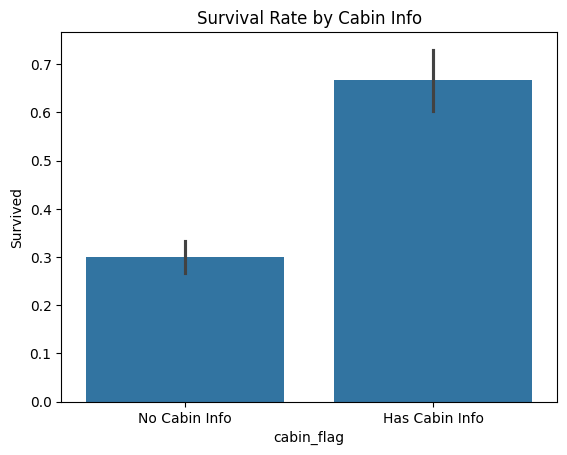

In [211]:
sns.barplot(x='cabin_flag', y='Survived', data=df)
plt.xticks([0, 1], ['No Cabin Info', 'Has Cabin Info'])
plt.title('Survival Rate by Cabin Info')
plt.show()

<Axes: xlabel='Survived', ylabel='Age'>

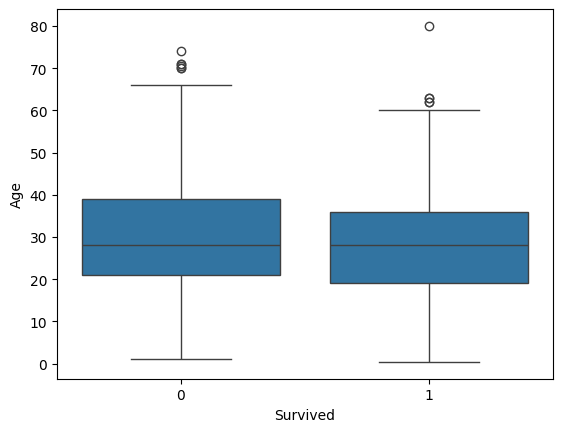

In [212]:
sns.boxplot(x='Survived', y='Age', data=df)

In [213]:
df_age_null_cleaned = df.dropna(subset=['Age'])

In [214]:
df['mean_age'] = df['Age'].fillna(df['Age'].mean()).astype(int)

In [215]:
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Embarked  cabin_flag  mean_age  
0      0         A/5 21171   7.2500        S           0        22  
1      0          PC 17599  71.2833        C           1        38  
2      0  STON/O2. 3101282   7.9250        S           0        26  
3      0            113803  53.1000        S

<Axes: xlabel='Survived', ylabel='Age'>

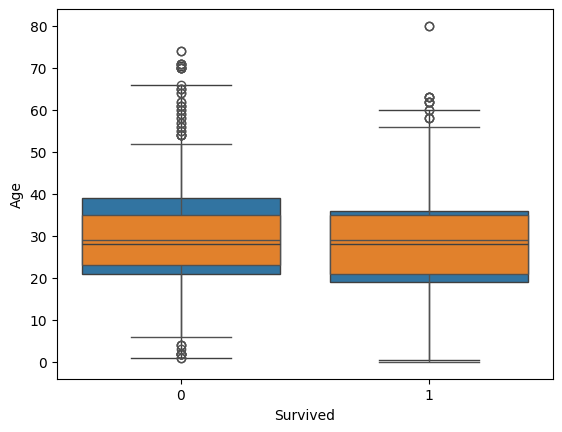

In [216]:
sns.boxplot(x='Survived', y='Age', data=df_age_null_cleaned )
sns.boxplot(x='Survived', y='mean_age', data=df)

In [217]:
df['median_age'] = df['Age'].fillna(df['Age'].median()).astype(int)

<Axes: xlabel='Survived', ylabel='Age'>

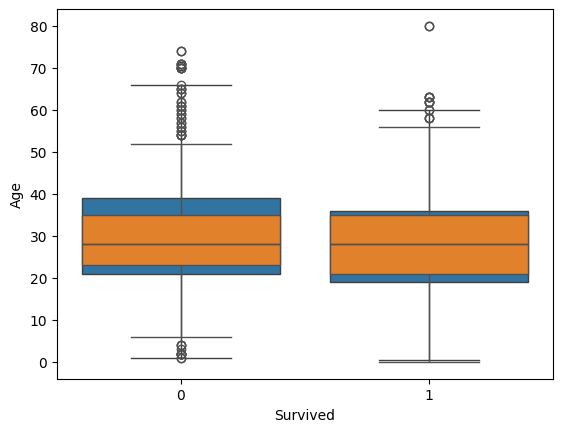

In [218]:
sns.boxplot(x='Survived', y='Age', data=df_age_null_cleaned )
sns.boxplot(x='Survived', y='median_age', data=df)

In [219]:
df['mode_age'] = df['Age'].fillna(df['Age'].mode()[0]).astype(int)

<Axes: xlabel='Survived', ylabel='Age'>

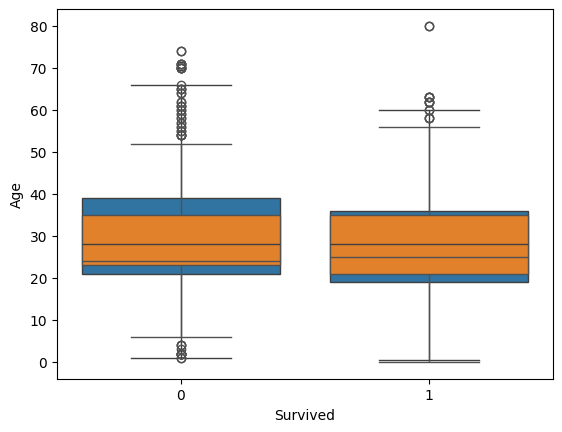

In [220]:
sns.boxplot(x='Survived', y='Age', data=df_age_null_cleaned )
sns.boxplot(x='Survived', y='mode_age', data=df)

<Axes: xlabel='Survived', ylabel='Age'>

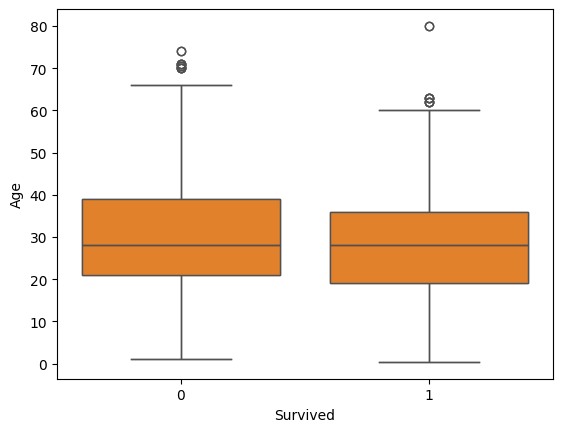

In [221]:
sns.boxplot(x='Survived', y='Age', data=df_age_null_cleaned )
sns.boxplot(x='Survived', y='Age', data=df)

In [222]:
df['Age'] = df['Age'].fillna(df['Age'].median()).astype(int)

In [223]:
df['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [224]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [225]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
cabin_flag     0
mean_age       0
median_age     0
mode_age       0
dtype: int64

In [226]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,cabin_flag,mean_age,median_age,mode_age
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,S,0,22,22,22
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C,1,38,38,38
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,S,0,26,26,26
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,S,1,35,35,35
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,S,0,35,35,35


In [227]:
scaler = StandardScaler()
df['Age_scaled'] = scaler.fit_transform(df[['Age']])
df['Fare_scaled'] = scaler.fit_transform(df[['Fare']])

In [228]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,cabin_flag,mean_age,median_age,mode_age,Age_scaled,Fare_scaled
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,S,0,22,22,22,-0.564145,-0.502445
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C,1,38,38,38,0.664649,0.786845
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,S,0,26,26,26,-0.256947,-0.488854
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,S,1,35,35,35,0.434250,0.420730
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,S,0,35,35,35,0.434250,-0.486337


In [229]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [230]:
df = pd.get_dummies(df, columns=['Embarked'], prefix='Embarked')

In [231]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,cabin_flag,mean_age,median_age,mode_age,Age_scaled,Fare_scaled,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22,1,0,A/5 21171,7.2500,0,22,22,22,-0.564145,-0.502445,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38,1,0,PC 17599,71.2833,1,38,38,38,0.664649,0.786845,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26,0,0,STON/O2. 3101282,7.9250,0,26,26,26,-0.256947,-0.488854,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35,1,0,113803,53.1000,1,35,35,35,0.434250,0.420730,False,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35,0,0,373450,8.0500,0,35,35,35,0.434250,-0.486337,False,False,True


In [232]:
df = df.drop(columns=[
    'PassengerId', 'Name', 'Ticket', 
    'Age', 'Fare', 'mean_age', 'median_age', 'mode_age'
])


In [233]:
df.head()

,Survived,Pclass,Sex,SibSp,Parch,cabin_flag,Age_scaled,Fare_scaled,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,1,0,0,-0.564145,-0.502445,False,False,True
1,1,1,1,1,0,1,0.664649,0.786845,True,False,False
2,1,3,1,0,0,0,-0.256947,-0.488854,False,False,True
3,1,1,1,1,0,1,0.434250,0.420730,False,False,True
4,0,3,0,0,0,0,0.434250,-0.486337,False,False,True


In [234]:
df['cabin_flag'] = df['cabin_flag'].astype(int)
df['Embarked_C'] = df['Embarked_C'].astype(int)
df['Embarked_Q'] = df['Embarked_Q'].astype(int)
df['Embarked_S'] = df['Embarked_S'].astype(int)


In [235]:
df.head()

,Survived,Pclass,Sex,SibSp,Parch,cabin_flag,Age_scaled,Fare_scaled,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,1,0,0,-0.564145,-0.502445,0,0,1
1,1,1,1,1,0,1,0.664649,0.786845,1,0,0
2,1,3,1,0,0,0,-0.256947,-0.488854,0,0,1
3,1,1,1,1,0,1,0.434250,0.420730,0,0,1
4,0,3,0,0,0,0,0.434250,-0.486337,0,0,1


In [236]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [237]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [238]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

